In [1]:
import numpy as np
from PIL import Image
import pandas as pd
import torchvision
import torch
import warnings
import os
from torch.utils.data import DataLoader, Dataset, random_split
import cv2
import matplotlib.pyplot as plt
from torchvision.io import decode_image
import seaborn as sns
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv('/kaggle/input/uw-madison-gi-tract-image-segmentation/train.csv')
train

,id,class,segmentation
0,case123_day20_slice_0001,large_bowel,NaN
1,case123_day20_slice_0001,small_bowel,NaN
2,case123_day20_slice_0001,stomach,NaN
3,case123_day20_slice_0002,large_bowel,NaN
4,case123_day20_slice_0002,small_bowel,NaN
...,...,...,...
115483,case30_day0_slice_0143,small_bowel,NaN
115484,case30_day0_slice_0143,stomach,NaN
115485,case30_day0_slice_0144,large_bowel,NaN
115486,case30_day0_slice_0144,small_bowel,NaN


### PREPROCESSING DATA

In [3]:

train['missed'] =  train.segmentation.notna()
train['segm'] = ''

for i in range(0, train.shape[0], 3):
    train.segm.iloc[i] = train.iloc[i:i+3].segmentation.to_numpy()
    train.missed.iloc[i] = train.iloc[i:i+3].missed.any()
print(train.info())  

train = train[::3]
train.reset_index(drop = True, inplace = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115488 entries, 0 to 115487
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            115488 non-null  object
 1   class         115488 non-null  object
 2   segmentation  33913 non-null   object
 3   missed        115488 non-null  bool  
 4   segm          115488 non-null  object
dtypes: bool(1), object(4)
memory usage: 3.6+ MB
None


In [5]:

train['path'] = '/kaggle/input/uw-madison-gi-tract-image-segmentation/train/'
train['splitted'] = train.id.agg(lambda x: x.split('_'))
train['case']     = train.splitted.agg(lambda x: str(x[0]))
train['day']      = train.splitted.agg(lambda x: str(x[1]))
train['slice']    = train.splitted.agg(lambda x: int(x[3].lstrip('0')))


cases = train.case.value_counts(sort = False)
cases_val, case_iter = cases.index, cases.values
case_iter = np.insert(case_iter, 0, 0)
case_iter = np.cumsum(case_iter)

for i in range(1, case_iter.shape[0]):
    
    temp_data = train.iloc[case_iter[i-1]:case_iter[i]]
    train.path.iloc[case_iter[i-1]:case_iter[i]] +=  cases_val[i-1]

    days = temp_data.day.value_counts(sort = False)
    day_val, day_iter = days.index, days.values
    day_iter = np.insert(day_iter, 0, 0)
    day_iter = np.cumsum(day_iter)

    for j in range(1, day_iter.shape[0]):
        
        val = '/'+cases_val[i-1]+'_'+day_val[j-1]+'/'+'scans/'
        train.path.iloc[case_iter[i-1]+day_iter[j-1]:day_iter[j]+case_iter[i-1]] +=  val

        list_of_files = sorted(os.listdir(train.path.iloc[case_iter[i-1]+day_iter[j-1]]))
        '''
        list_of_files = np.repeat(list_of_files, 
                                  np.ones(len(list_of_files), dtype = np.int8)*3)
        '''
        train.path.iloc[case_iter[i-1]+day_iter[j-1]:day_iter[j]+case_iter[i-1]] +=  list_of_files
        

In [46]:
indexes = train[train['missed'] == True].index

train['segmented classes'] = 'no one classes'
train['segmented classes'].iloc[indexes] == 'all classes'


train['stomach'] = False
train['large_bowel'] = False
train['small_bowel'] = False

missed_classes = np.array(['large_bowel\n', 'small_bowel\n', 'stomach'])
for i in indexes:

    states = pd.notnull(train.segm.iloc[i])
   
    train['large_bowel'].iloc[i] = states[0]
    train['small_bowel'].iloc[i] = states[1]
    train['stomach'].iloc[i] = states[2]

    states = np.where(states)[0]
    
    missed_class = "  ".join(missed_classes[states].tolist())
    train['segmented classes'].iloc[i] = missed_class

    

In [47]:
train['No one label'] = train['segmented classes'] == 'no one classes'
train

,id,class,segmentation,missed,segm,path,splitted,case,day,slice,сlass,stomach,large_bowel,small_bowel,segmented classes,image_shape,No one label
0,case123_day20_slice_0001,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0001]",case123,day20,1,noone classes,False,False,False,no one classes,266_266,True
1,case123_day20_slice_0002,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0002]",case123,day20,2,noone classes,False,False,False,no one classes,266_266,True
2,case123_day20_slice_0003,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0003]",case123,day20,3,noone classes,False,False,False,no one classes,266_266,True
3,case123_day20_slice_0004,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0004]",case123,day20,4,noone classes,False,False,False,no one classes,266_266,True
4,case123_day20_slice_0005,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case123, day20, slice, 0005]",case123,day20,5,noone classes,False,False,False,no one classes,266_266,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38491,case30_day0_slice_0140,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day0, slice, 0140]",case30,day0,140,noone classes,False,False,False,no one classes,266_266,True
38492,case30_day0_slice_0141,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day0, slice, 0141]",case30,day0,141,noone classes,False,False,False,no one classes,266_266,True
38493,case30_day0_slice_0142,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day0, slice, 0142]",case30,day0,142,noone classes,False,False,False,no one classes,266_266,True
38494,case30_day0_slice_0143,large_bowel,NaN,False,"[nan, nan, nan]",/kaggle/input/uw-madison-gi-tract-image-segmen...,"[case30, day0, slice, 0143]",case30,day0,143,noone classes,False,False,False,no one classes,266_266,True


### **DATA ANALYSIS**

#### Distribution of labels and background 

In [65]:
cases = train.groupby(['case'])[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].any().reset_index()
cases[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].all()

No one label    True
stomach         True
large_bowel     True
small_bowel     True
dtype: bool

In [71]:
cases[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].sum()

No one label    85
stomach         85
large_bowel     85
small_bowel     85
dtype: int64

In [73]:
days = train.groupby(['case', 'day'])[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].any()
days[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].all()

No one label     True
stomach          True
large_bowel     False
small_bowel      True
dtype: bool

In [74]:
days[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].sum()

No one label    274
stomach         274
large_bowel     273
small_bowel     274
dtype: int64

We can see large_bowel label hasn't been presented in one day. But it's not crucial because we'll spliting data into training and validation set by cases, in turn all labels are presented in each case. 

In [75]:
slices = train.groupby(['case', 'day', 'slice'])[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].any()
slices[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].sum()

No one label    21906
stomach          8627
large_bowel     14085
small_bowel     11201
dtype: int64

Here we can see an absence of all clases prevails in dataset. So in the future we need to penalize our loss to have more recall on labels 

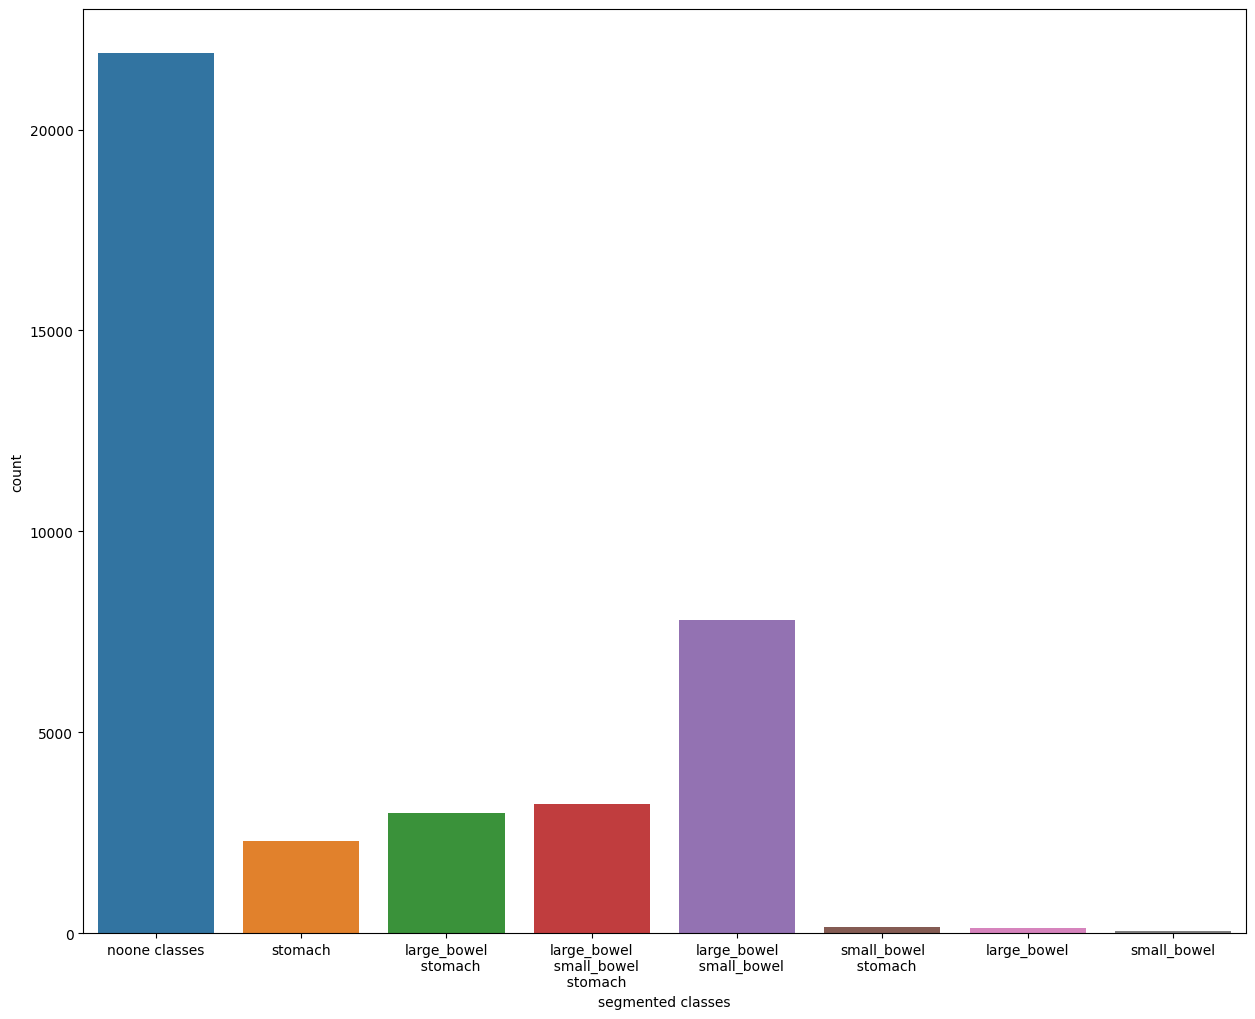

In [37]:

fig, ax = plt.subplots(figsize=(15, 12))
ax = sns.countplot(data = train, x = 'segmented classes' )
plt.show()

In [77]:
from sklearn.model_selection import train_test_split
cases = train.case.unique()
cases_train, cases_valid = train_test_split(
   cases, test_size=0.1, random_state=42
)
cases_train
trainset, validset = train[train['case'].isin(cases_train)], train[train['case'].isin(cases_valid)]

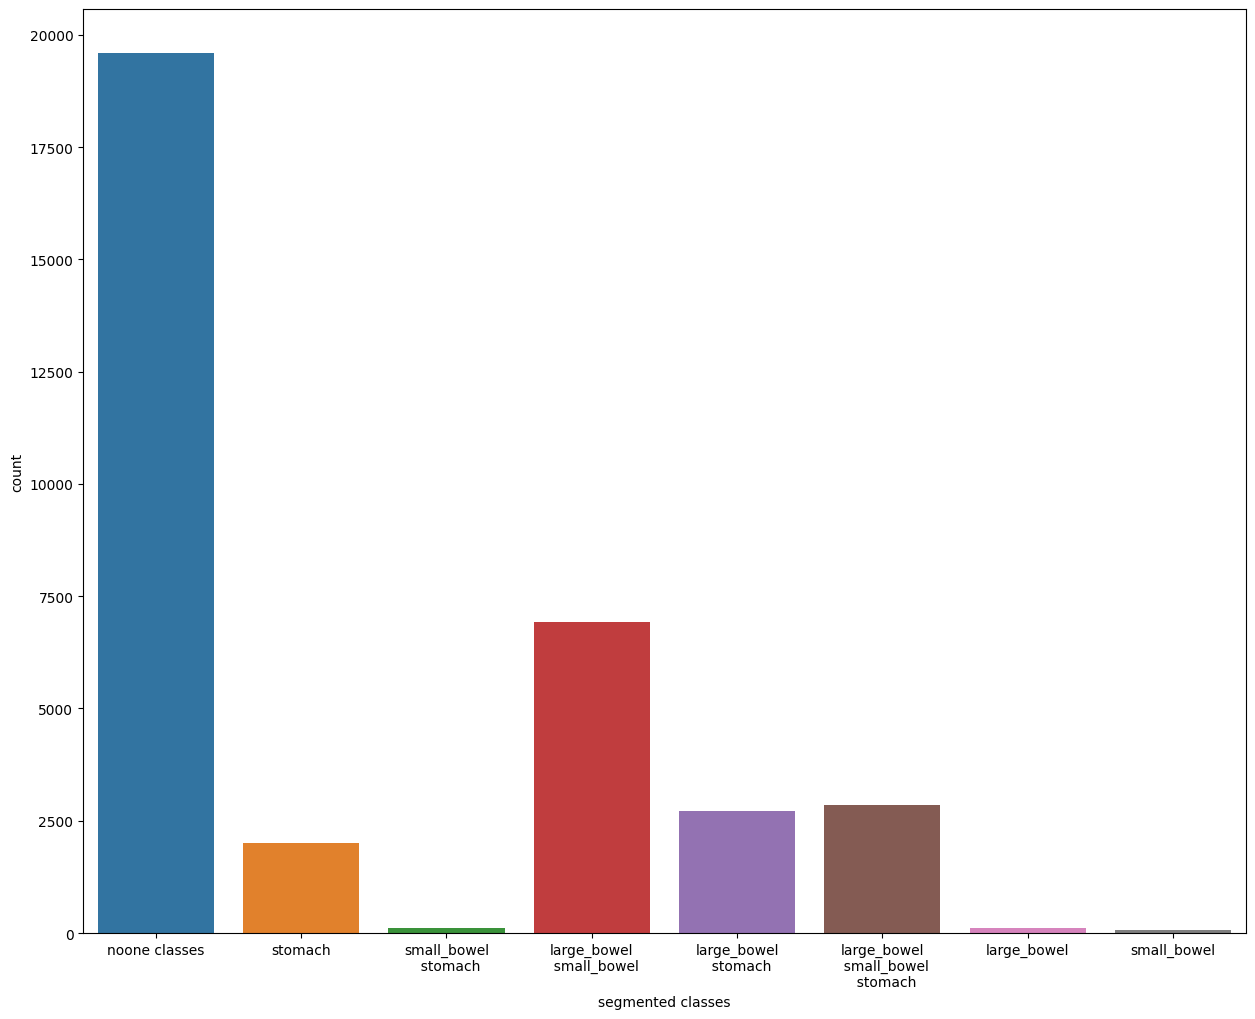

In [38]:

fig, ax = plt.subplots(figsize=(15, 12))
ax = sns.countplot(data = train[train['case'].isin(cases_train)], x = 'segmented classes' )
plt.show()

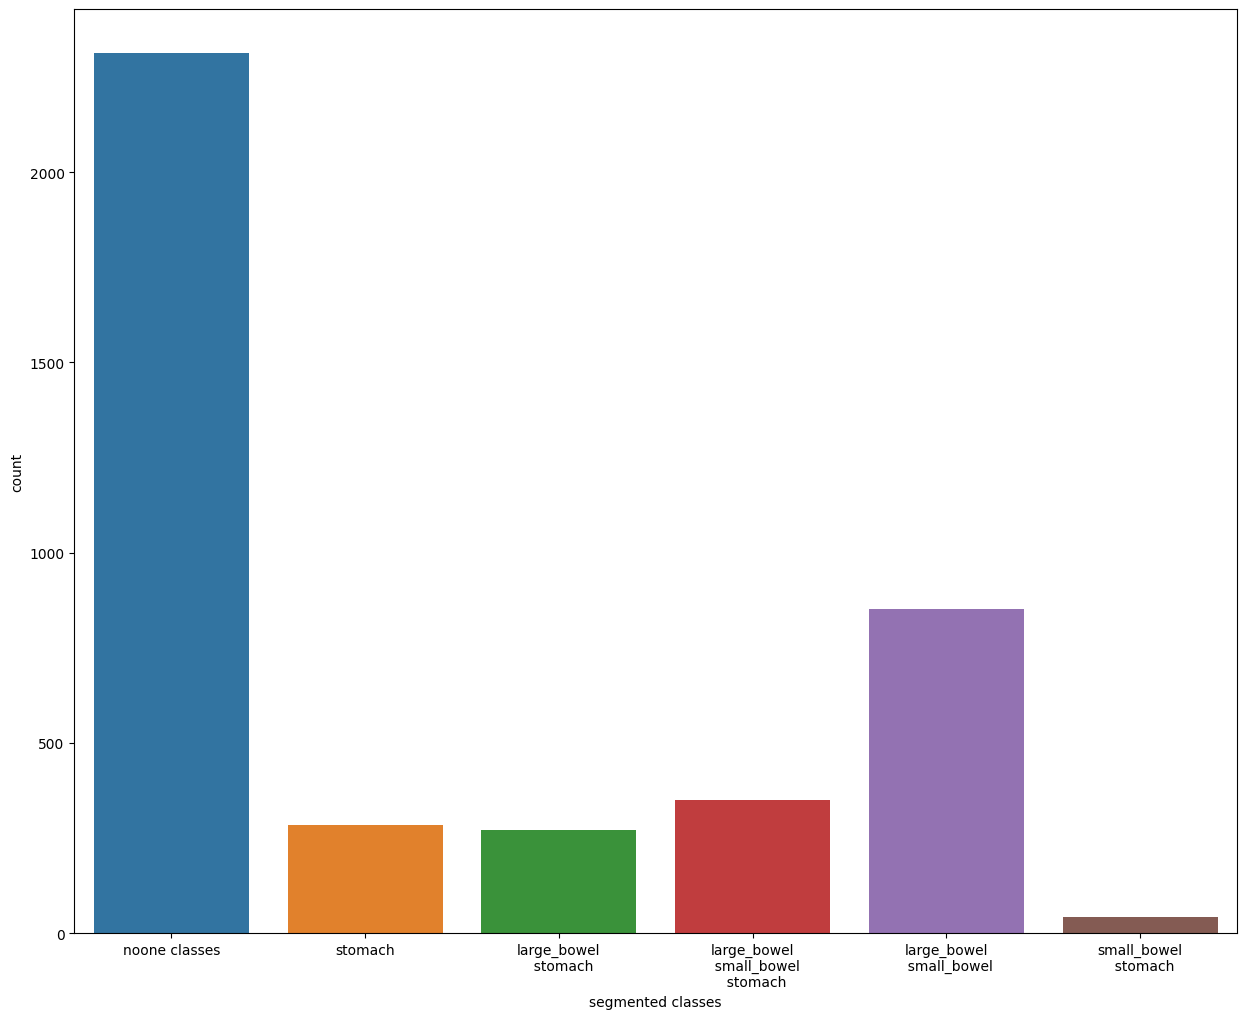

In [39]:

fig, ax = plt.subplots(figsize=(15, 12))
ax = sns.countplot(data = train[train['case'].isin(cases_valid)], x = 'segmented classes' )
plt.show()

In [94]:
days_train = trainset.groupby(['case', 'day', 'slice'])[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].any()[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].sum().reset_index()
days_valid = validset.groupby(['case', 'day', 'slice'])[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].any().reset_index()[['No one label', 'stomach', 	
                          'large_bowel',  'small_bowel']].sum().reset_index()


days_train['Proportion'] = days_train.shape[0] / days_train[0]
days_valid['Proportion'] = days_valid.shape[0] / days_valid[0]

abs(days_train['Proportion'] - days_valid['Proportion'])

0    0.001525
1    0.003703
2    0.002397
3    0.002814
Name: Proportion, dtype: float64

Distribution of labels between training and validation set is almost same

In [31]:
train['image_shape'] = pd.NA 

for i in range(train.shape[0]):

     train.image_shape.iloc[i] = train.path.iloc[i][-21:-14]

print(train.image_shape.value_counts())

image_shape
266_266    25920
360_310    11232
276_276     1200
234_234      144
Name: count, dtype: int64


In [35]:
train.groupby(['case', 'day'])['image_shape'].nunique().unique()

array([1])

Shapes of images among all days in each cases are the same. So we don't need to pad them, then we will preprocessing data for model 

In [40]:
data_360 = train[train['image_shape'] == '360_310']
data_360.case.unique()
data_360.reset_index(drop=True, inplace=True)

cases = data_360.case.value_counts(sort = False)
cases_val, case_iter = cases.index, cases.values
case_iter = np.insert(case_iter, 0, 0)
case_iter = np.cumsum(case_iter)

fig,ax = plt.subplots(5, 5, figsize = (16, 18), dpi = 600)
for i in range(5):
    for j in range(1, 6):
        image = cv2.imread(data_360.path.iloc[case_iter[(i*(j-1))+j-1]], 
                           cv2.IMREAD_ANYDEPTH)
        ax[i, j-1].imshow(image, cmap = 'gray')
        ax[i, j-1].axis('off')
    
    

In [41]:
data_276 = train[train['image_shape'] == '276_276']
data_276.case.unique()
data_276.reset_index(drop=True, inplace=True)

cases = data_276.case.value_counts(sort = False)
cases_val, case_iter = cases.index, cases.values
case_iter = np.insert(case_iter, 0, 0)
case_iter = np.cumsum(case_iter)

fig,ax = plt.subplots(4, 2, figsize = (16, 18), dpi = 600)
for i in range(4):
    for j in range(1, 3):
        image = cv2.imread(data_276.path.iloc[case_iter[(i*(j-1))+j-1]], 
                           cv2.IMREAD_ANYDEPTH)
        ax[i, j-1].imshow(image, cmap = 'gray')
        ax[i, j-1].axis('off')